In [415]:
import numpy as np
import pickle
import pandas as pd
import yaml
import os
from matplotlib import pyplot as plt

In [416]:
from hsa_hopper.collocation import interp_covector, diff_tensor

def smooth_dynamics(df):
    degree = 5
    window = 20
    x = df['x_rad'].to_numpy()
    tau = df['torque'].to_numpy()
    t = df['t_s'].to_numpy(copy=True)
    t = t-t[0]
    x_filt = np.zeros_like(x)
    xdot = np.zeros_like(x)
    xddot = np.zeros_like(x)
    tau_filt = np.zeros_like(x)
    for i in range(window//2, t.size-window//2):

        if i-window//2 < 0:
            start_idx = 0
            stop_idx = window
        elif i+window//2 >= t.size:
            start_idx = t.size-window//2-1
            stop_idx = t.size
        else:
            start_idx = i-window//2
            stop_idx = start_idx + window

        stop_idx = min(t.size,start_idx+window)
        A = np.vstack([
            interp_covector(t[j],t[start_idx],t[stop_idx-1],degree+1)
                for j in range(start_idx,stop_idx)
        ])
        x_coeffs, res, rank, s = np.linalg.lstsq(A,x[start_idx:stop_idx],rcond=None)
        dt = diff_tensor(t[start_idx],t[stop_idx-1],degree+1)
        t_eval = interp_covector(t[i], t[start_idx], t[stop_idx-1], degree+1)

        x_filt[i] = np.dot(t_eval, x_coeffs)[0]
        xdot_coeffs = dt@x_coeffs
        xdot[i] = np.dot(t_eval, xdot_coeffs)[0]
        xddot[i] = np.dot(t_eval, dt@xdot_coeffs)[0]

        tau_coeffs, res, rank, s = np.linalg.lstsq(A,tau[start_idx:stop_idx],rcond=None)
        tau_filt[i] = np.dot(t_eval, tau_coeffs)[0]

    df['x_rad'] = x_filt
    df['xdot'] = xdot
    df['xddot'] = xddot
    df['torque'] = tau_filt
    return df

In [417]:
from hsa_hopper.kinematics import KinematicParameters, forward_kinematics

def compute_kinematics(df: pd.DataFrame, params: KinematicParameters):
    x = df['x_rad'].to_numpy()
    xdot = df['xdot'].to_numpy()
    xddot = df['xddot'].to_numpy()

    fk, jac, hess = forward_kinematics(params, x, jacobian=True, hessian=True)
    y = fk[0]
    l = fk[1]

    dydx = jac[0]    
    ydot = jac[0]*xdot

    d2yd2x = hess[0]
    yddot = dydx*xddot + xdot*d2yd2x*xdot

    dldx = jac[1]
    ldot = dldx*xdot

    d2ld2x = hess[1]
    lddot = dldx*xddot + xdot*d2ld2x*xdot

    df['y_m'] = y
    df['l_m'] = l
    df['dydx'] = dydx
    df['ydot'] = ydot
    df['dldx'] = dldx
    df['ldot'] = ldot
    df['d2yd2x'] = d2yd2x
    df['yddot'] = yddot
    df['d2ld2x'] = d2yd2x
    df['lddot'] = lddot

    return df

In [418]:
"""
Load all data from the HSA characterization dataset
"""
experiment_folder = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/3_27_25/no_hsa_identification/2025-03-27_1743119682'

with open(os.path.join(experiment_folder, 'experiment_config.yaml'), 'r') as f:
    experiment_config = yaml.load(f, yaml.Loader)

with open(os.path.join(experiment_folder, 'hardware_config.yaml'), 'r') as f:
    hardware_config = yaml.load(f, yaml.Loader)

from hsa_hopper.kinematics import KinematicParameters
kin_params = KinematicParameters(
    hardware_config['kinematics']['a'],
    hardware_config['kinematics']['b'],
    hardware_config['kinematics']['c'],
    hardware_config['kinematics']['d'],
)

path = os.path.join(experiment_folder, '0_deg.csv')
df = smooth_dynamics(pd.read_csv(path))
compute_kinematics(df, kin_params)
print(len(df))
df = df.iloc[10:len(df)-10,:]
print(len(df))

13420
13400


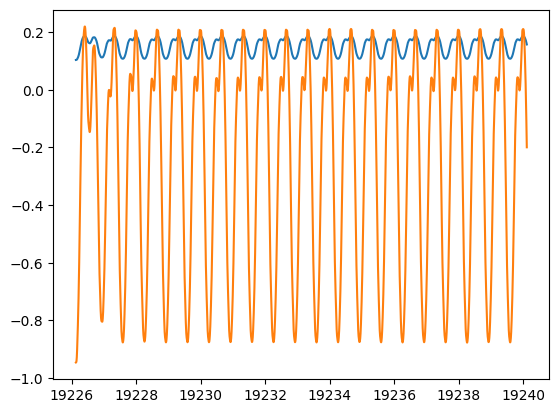

In [419]:
from matplotlib import pyplot as plt
# plt.plot(df['t_s'], df['xdot'])
t = df['t_s'].to_numpy()
t = t - t[0]
x = df['x_rad'].to_numpy()
xdot = df['xdot'].to_numpy()
# plt.plot(t,xdot)
# plt.plot(t[:-1], np.diff(x)/np.diff(t))
plt.plot(df['t_s'], df['l_m'])
plt.plot(df['t_s'], df['x_rad'])


In [420]:
from numpy.random import default_rng

N_ROWS = len(df)
rng = default_rng(seed=42)
TRAIN_INDICES = rng.choice(N_ROWS, 7*N_ROWS//10, replace=False)

In [421]:
from hsa_hopper.hsa_model import HSAPotential
def make_lstsq_data(row_indices):
    DATA_COLUMN_MAP = {key : i for i, key in enumerate(df.columns)}
    M = len(row_indices)
    A = np.zeros((M,4))
    b = np.zeros(M)
    for i, idx in enumerate(row_indices):
        l = df.iloc[idx,DATA_COLUMN_MAP['l_m']]
        xdot = df.iloc[idx,DATA_COLUMN_MAP['xdot']]
        ldot = df.iloc[idx,DATA_COLUMN_MAP['ldot']]
        xddot = df.iloc[idx,DATA_COLUMN_MAP['xddot']]
        lddot = df.iloc[idx,DATA_COLUMN_MAP['lddot']]
        tau = df.iloc[idx,DATA_COLUMN_MAP['torque']]
        dldx = df.iloc[idx,DATA_COLUMN_MAP['dldx']]
        d2ld2x = df.iloc[idx,DATA_COLUMN_MAP['d2ld2x']]
        b[i] = tau
        A[i,0] = xddot                      # column 0 -> motor inertia
        A[i,1] = xdot                       # column 1 -> motor damping
        A[i,2] = (lddot+9.81)*dldx+ldot*d2ld2x*xdot# column 2 -> leg inertia
        A[i,3] = ldot*dldx                       # column 3 -> leg damping
    return A,b

In [422]:
"""
Experimental - fitting two potential functions and blending them together with a logistic function
"""

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint
from hsa_hopper.hsa_model import HSAPotential

# function to do the model optimization
def governing_equation_lstsq():
    # N = model.num_params()
    A,b = make_lstsq_data(TRAIN_INDICES)

    # rescaling A matrix for better conditioning of constraint evaluation
    SCALE = np.ones(A.shape[1])
    SCALE[0] = 1/1000   # motor inertia rescaling
    SCALE[1] = 1/1000   # motor damping rescaling
    SCALE[2] = 1/100    # leg inertia rescaling
    SCALE[3] = 1        # leg damping rescaling

    A_scaled = A*SCALE
    ATA = A_scaled.T@A_scaled
    ATb = A_scaled.T@b
    bTb = np.dot(b,b)
    f = lambda x: x.T@ATA@x+bTb-2*x.T@ATb
    jac = lambda x: 2*ATA@x-2*ATb

    # rescaling matrix for parameters, useful for conditioning
    # the constraint evaluations

    # next constraints - enforce positive weights
    # and positive definiteness of stiffness/damping at basis centers
    C = np.eye(4)
    lb = np.array([1., 0, 0, 0])
    ub = np.array([5., 50, 100, 10])
    constraints = [LinearConstraint(C,lb=lb,ub=ub)]

    x0 = np.zeros(4)
    x0[0] = 3.5
    x0[2] = 10.
    result = minimize(f, x0, 
                    jac=jac, 
                    constraints=constraints, 
                    method='SLSQP',
                    options={'maxiter' : 12000}
    )
    result.A = A
    result.b = b
    result.sample_size = b.shape[0]
    # result.num_params = model.num_params()
    result.num_params = 4
    result.J_x = result.x[0]*SCALE[0]
    result.b_x = result.x[1]*SCALE[1]
    result.m_foot = result.x[2]*SCALE[2]
    result.b_leg = result.x[3]*SCALE[3]
    # if model.kind != HSAPotential.LINEAR:
    #     N_d = model.w_d.shape[0]
    #     model.w_d = result.x[4:]
    # result.model = model
    result.r_sqr = 1-result.fun/np.sum((b-np.average(b))**2)
    result.r_sqr_adj = 1-(1-result.r_sqr)*(result.sample_size-1)/(result.sample_size-result.num_params-1)
    result.mse = result.fun/result.sample_size
    result.rmse = np.sqrt(result.mse)
    result.bic = result.sample_size*np.log(result.mse)+result.num_params*np.log(result.sample_size)
    result.errors = A@(SCALE*result.x)-b
    return result 
    

In [426]:
# choosing an optimal (s) for a linear damping model according to the number of basis functions
result = governing_equation_lstsq()

import yaml
with open('no_hsa_model.yaml', 'w') as f:
    yaml.dump({
        'J' : float(result.J_x),
        'm_foot' : float(result.m_foot),
        'bx' : float(result.b_x),
        'bl' : float(result.b_leg)
    }, f, yaml.Dumper)